# CNN Demo Notebook

What this notebook shows:
- how the dataset is loaded
- load the created test set and the best CNN model from `models/cnn`
- a few example MRI images from each class
- evaluating the CNN on the test set
- sample predictions on real test images
- a few mistakes / hardest examples to make the demo more interesting

In [1]:
# Basic imports for the demo.
import os
import glob
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# I set a default plot size so the notebook visuals look cleaner.
plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
# Change these paths if your folder structure is a bit different on your machine.
PROJECT_ROOT = Path(".").resolve()
DATASET_DIR = PROJECT_ROOT / "../data/brain_tumor_dataset"
MODEL_DIR = PROJECT_ROOT / "../models/cnn"
MODEL_PATH = MODEL_DIR / "best_cnn_model.pt"
TEST_SPLIT_PATH = MODEL_DIR / "test_split.csv"

IMG_SIZE = 64

print("PROJECT_ROOT    =", PROJECT_ROOT)
print("DATASET_DIR     =", DATASET_DIR)
print("MODEL_PATH      =", MODEL_PATH)
print("TEST_SPLIT_PATH =", TEST_SPLIT_PATH)

PROJECT_ROOT    = /Users/naghamsabbour/Documents/UofT/Courses/ECE1513/Project/Brain-Tumor-Detection/notebooks
DATASET_DIR     = /Users/naghamsabbour/Documents/UofT/Courses/ECE1513/Project/Brain-Tumor-Detection/notebooks/../data/brain_tumor_dataset
MODEL_PATH      = /Users/naghamsabbour/Documents/UofT/Courses/ECE1513/Project/Brain-Tumor-Detection/notebooks/../models/cnn/best_cnn_model.pt
TEST_SPLIT_PATH = /Users/naghamsabbour/Documents/UofT/Courses/ECE1513/Project/Brain-Tumor-Detection/notebooks/../models/cnn/test_split.csv


## 1. Dataset overview

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


,class,count,percent
0,glioma,3754,35.549242
1,meningioma,2343,22.187500
2,no_tumor,1757,16.638258
3,pituitary,2706,25.625000


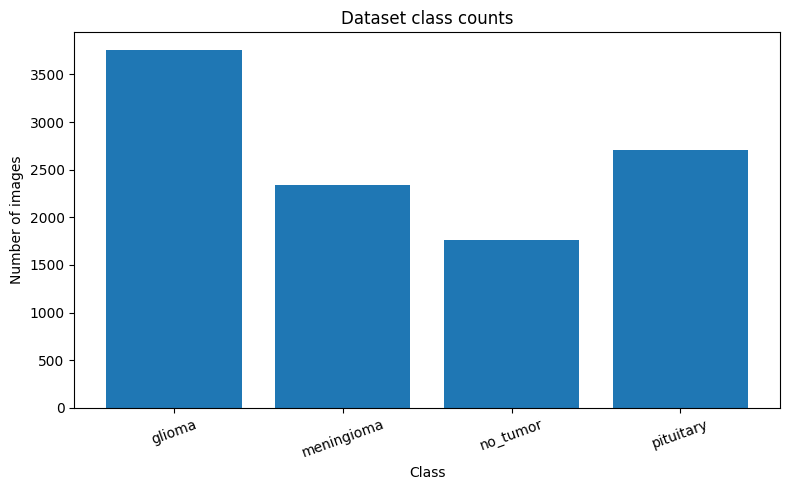

In [7]:
# Read the class folders and count how many images belong to each class.
assert DATASET_DIR.exists(), f"Dataset folder not found: {DATASET_DIR}"

class_names = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
counts = {}

for class_name in class_names:
    class_dir = DATASET_DIR / class_name
    image_files = [p for p in class_dir.iterdir() if p.is_file()]
    counts[class_name] = len(image_files)

counts_df = pd.DataFrame({
    "class": list(counts.keys()),
    "count": list(counts.values()),
})
counts_df["percent"] = 100 * counts_df["count"] / counts_df["count"].sum()

print("Classes:", class_names)
display(counts_df)

plt.figure()
plt.bar(counts_df["class"], counts_df["count"])
plt.title("Dataset class counts")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 2. Load the MRI images

Preprocessing:
- grayscale
- resize to 64x64
- normalize pixels to [0, 1]

In [8]:
# This helper loads every image from the class folders and keeps the file paths too.
def load_images_from_folders(base_path, img_size=64):
    images = []
    labels = []
    filepaths = []

    class_names_local = sorted([d.name for d in Path(base_path).iterdir() if d.is_dir()])

    for label, class_name in enumerate(class_names_local):
        class_dir = Path(base_path) / class_name
        for file_path in sorted(class_dir.iterdir()):
            if not file_path.is_file():
                continue

            img = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(label)
            filepaths.append(str(file_path))

    return np.array(images), np.array(labels), np.array(filepaths), class_names_local


images, labels, filepaths, class_names = load_images_from_folders(DATASET_DIR, img_size=IMG_SIZE)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Class names:", class_names)

Images shape: (10560, 64, 64)
Labels shape: (10560,)
Class names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## 3. Load the exact saved test split

Instead of splitting the dataset again, this notebook loads the exact `test_split.csv` that belongs to the trained CNN model.

In [9]:
# I load the exact saved test split so the demo uses the same test set as training.
assert TEST_SPLIT_PATH.exists(), f"Could not find saved test split: {TEST_SPLIT_PATH}"

test_df = pd.read_csv(TEST_SPLIT_PATH)

print("Saved test split preview:")
display(test_df.head())

print("Number of test examples:", len(test_df))
print("Test class distribution:")
display(test_df["class_name"].value_counts())

Saved test split preview:


,filepath,label,class_name
0,data/brain_tumor_dataset/pituitary/pituitary10...,3,pituitary
1,data/brain_tumor_dataset/glioma/glioma3368.jpg,0,glioma
2,data/brain_tumor_dataset/pituitary/pituitary91...,3,pituitary
3,data/brain_tumor_dataset/glioma/glioma831.png,0,glioma
4,data/brain_tumor_dataset/meningioma/meningioma...,1,meningioma


Number of test examples: 1584
Test class distribution:


class_name
glioma        563
pituitary     406
meningioma    351
no_tumor      264
Name: count, dtype: int64

In [16]:
# Rebuild the exact test set from the saved CSV file.
X_test = []
y_test = []
fp_test = []

for _, row in test_df.iterrows():
    img = cv2.imread(str((PROJECT_ROOT / '..' / row["filepath"]).resolve()), cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    X_test.append(img)
    y_test.append(int(row["label"]))
    fp_test.append(row["filepath"])

X_test = np.array(X_test)
y_test = np.array(y_test)
fp_test = np.array(fp_test)

print("Exact test set shape:", X_test.shape, y_test.shape)
print("Unique labels in test set:", np.unique(y_test))

Exact test set shape: (1584, 64, 64) (1584,)
Unique labels in test set: [0 1 2 3]


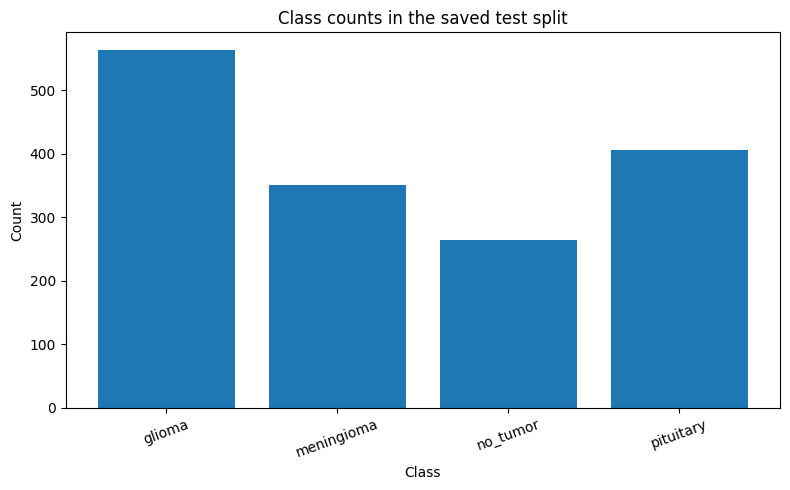

In [17]:
# This just visualizes the saved test set class balance.
test_counts = test_df["class_name"].value_counts().reindex(class_names, fill_value=0)

plt.figure()
plt.bar(test_counts.index, test_counts.values)
plt.title("Class counts in the saved test split")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Show a few sample images from each class

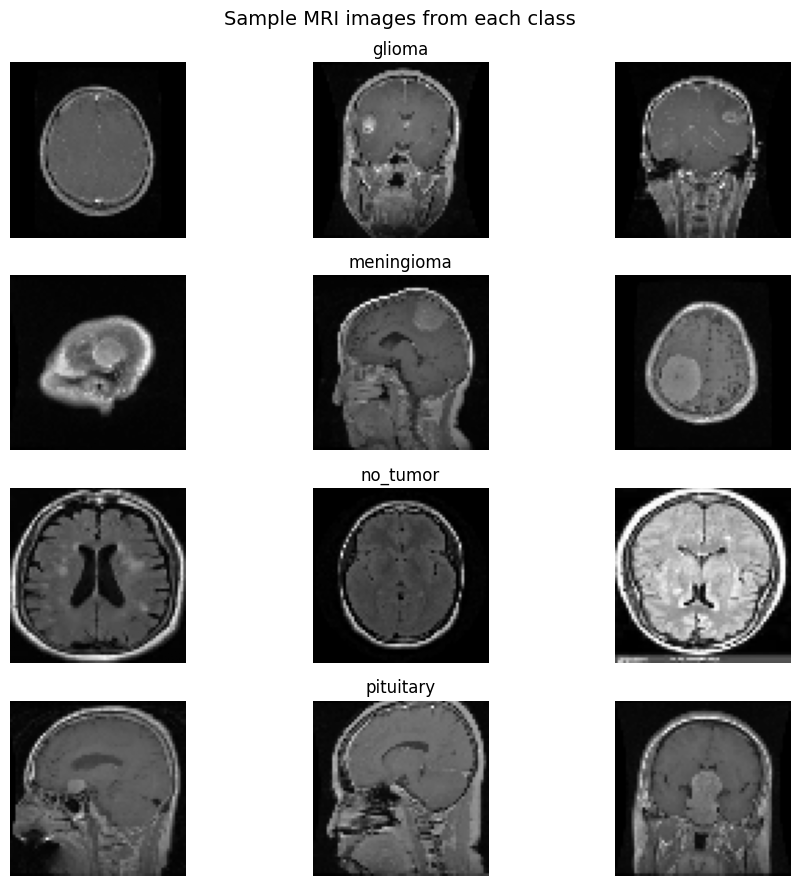

In [18]:
# I show 3 example images from each class.
samples_per_class = 3

fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(10, 9))
fig.suptitle("Sample MRI images from each class", fontsize=14)

for row, class_name in enumerate(class_names):
    class_idx = class_names.index(class_name)
    idxs = np.where(labels == class_idx)[0][:samples_per_class]

    for col in range(samples_per_class):
        ax = axes[row, col] if len(class_names) > 1 else axes[col]
        if col < len(idxs):
            ax.imshow(images[idxs[col]], cmap="gray")
            if col == 1:
                ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Define the CNN architecture

In [19]:
# This is the deeper CNN version used for the final model
class BrainTumorCNN(nn.Module):
    # The model takes 64x64 grayscale images and predicts 1 of 4 classes
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 6. Run the trained CNN on the test set

In [20]:
# I load the saved weights and evaluate the model on the held-out test set
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("Using device:", device)

assert MODEL_PATH is not None, "No .pt model file was found in models/cnn."

model = BrainTumorCNN(num_classes=len(class_names))
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)

with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

test_acc = accuracy_score(y_test, preds)
report = classification_report(y_test, preds, target_names=class_names, digits=4)
cm = confusion_matrix(y_test, preds)

print(f"Test accuracy: {test_acc:.4f}")
print(report)
print("Confusion matrix:")
print(cm)

Using device: mps
Test accuracy: 0.9792
              precision    recall  f1-score   support

      glioma     0.9856    0.9734    0.9794       563
  meningioma     0.9605    0.9687    0.9645       351
    no_tumor     0.9849    0.9886    0.9868       264
   pituitary     0.9829    0.9901    0.9865       406

    accuracy                         0.9792      1584
   macro avg     0.9785    0.9802    0.9793      1584
weighted avg     0.9792    0.9792    0.9792      1584

Confusion matrix:
[[548  11   3   1]
 [  6 340   0   5]
 [  2   0 261   1]
 [  0   3   1 402]]


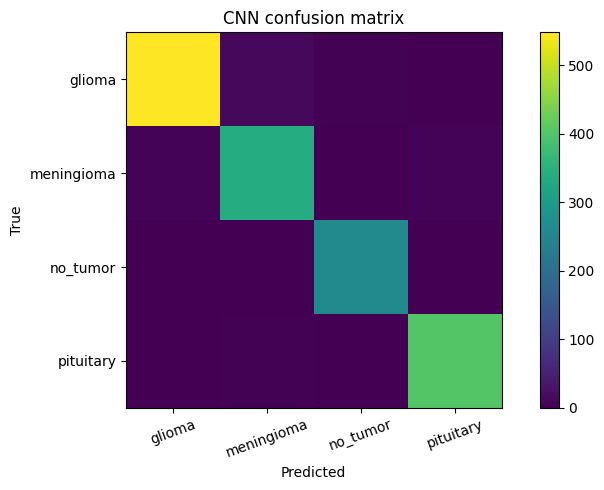

In [21]:
# The confusion matrix helps show which classes the CNN confuses the most.
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("CNN confusion matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=20)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 7. Show a few correct and incorrect predictions

In [23]:
# I separate correct and incorrect test examples to make the demo more interesting.
correct_idx = np.where(preds == y_test)[0]
wrong_idx = np.where(preds != y_test)[0]

print("Number correct:", len(correct_idx))
print("Number wrong:", len(wrong_idx))

Number correct: 1551
Number wrong: 33


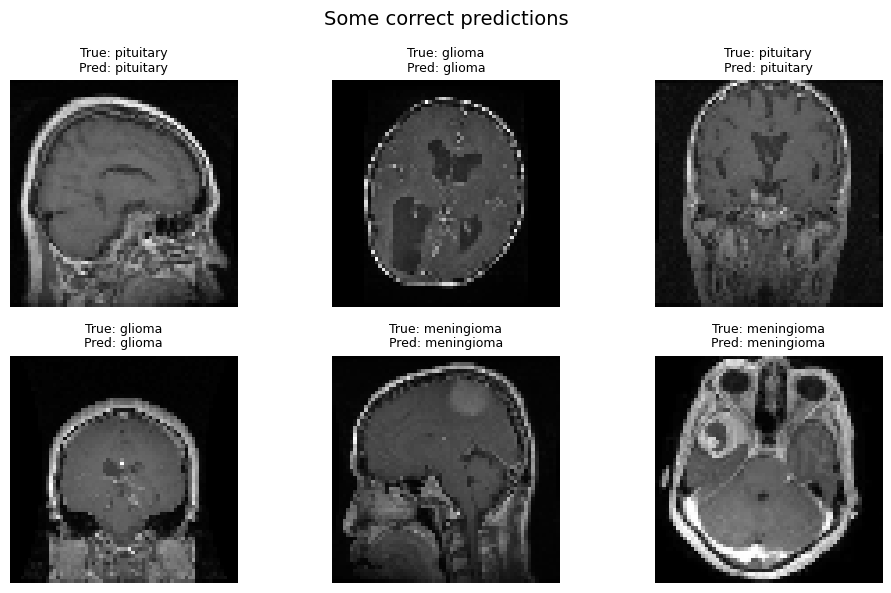

In [24]:
# Show some correct predictions.
show_n = min(6, len(correct_idx))
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, idx in zip(axes, correct_idx[:show_n]):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[preds[idx]]}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Some correct predictions", fontsize=14)
plt.tight_layout()
plt.show()

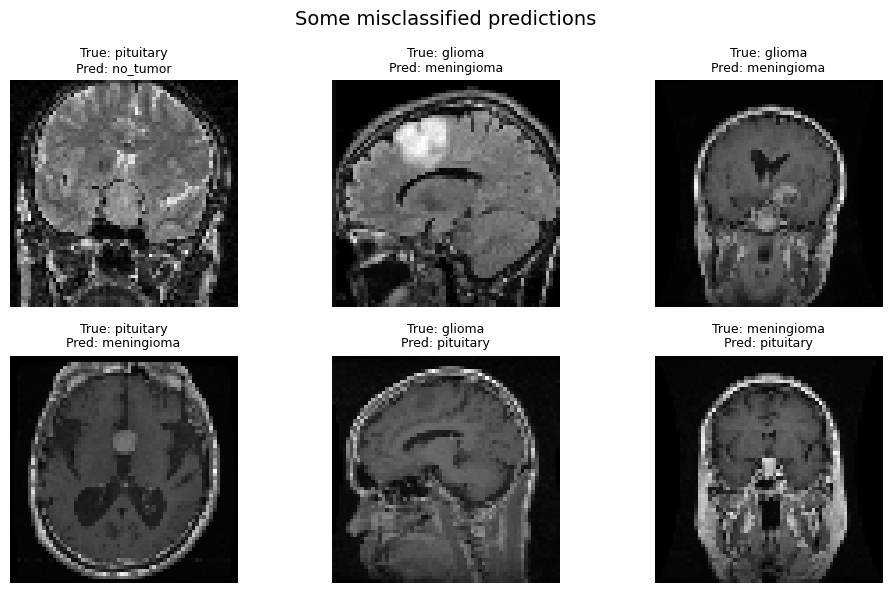

In [25]:
# Show some misclassified predictions.
show_n = min(6, len(wrong_idx))
if show_n == 0:
    print("Nice, no mistakes to show in this run.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.flatten()

    for ax, idx in zip(axes, wrong_idx[:show_n]):
        ax.imshow(X_test[idx], cmap="gray")
        ax.set_title(
            f"True: {class_names[y_test[idx]]}\nPred: {class_names[preds[idx]]}",
            fontsize=9
        )
        ax.axis("off")

    plt.suptitle("Some misclassified predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Show the most confident predictions

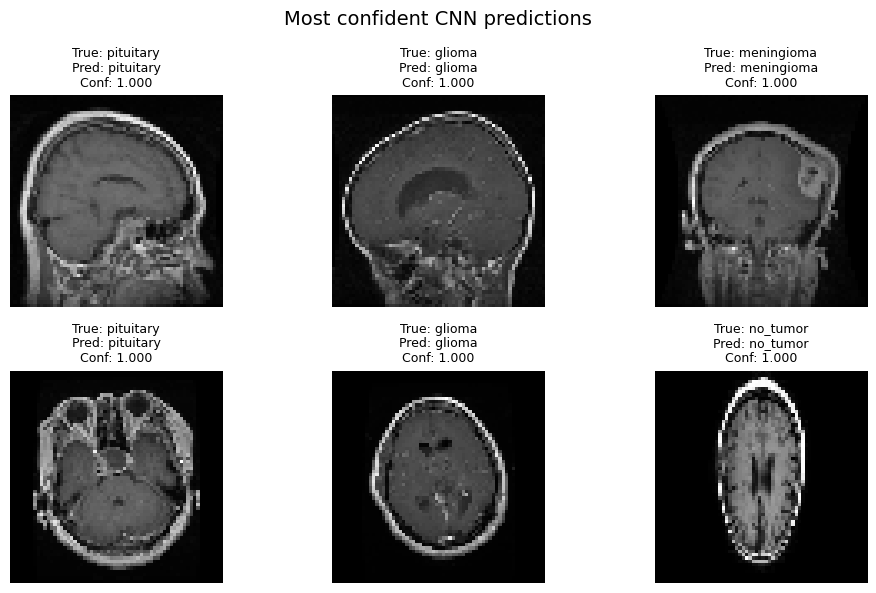

In [26]:
# I sort predictions by confidence and show a few of the most confident ones.
confidence = probs.max(axis=1)
top_idx = np.argsort(-confidence)[:6]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, idx in zip(axes, top_idx):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[preds[idx]]}\nConf: {confidence[idx]:.3f}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Most confident CNN predictions", fontsize=14)
plt.tight_layout()
plt.show()